# Kwant — Theory and Practice · Chapter 3
## Graphene and superconductivity

*Part I · Sections 8–9 · Figures 14–18* &nbsp;·&nbsp; [← Chapter 2](02_Shapes_Spin_and_Bands.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 4 →](04_Observables_and_Visualisation.ipynb)

### In this chapter

- [8. Beyond square lattices — graphene](#8.-Beyond-square-lattices-—-graphene)
    - [Graphene](#Graphene)
- [9. Superconductivity — BdG, Andreev reflection, and discrete symmetries](#9.-Superconductivity-—-BdG,-Andreev-reflection,-and-discrete-symmetries)
    - [The Bogoliubov–de Gennes construction](#The-Bogoliubov–de-Gennes-construction)
    - [Andreev reflection and the BTK conductance](#Andreev-reflection-and-the-BTK-conductance)
    - [Telling Kwant about the structure](#Telling-Kwant-about-the-structure)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 14–18, so the counter starts at 13.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [13]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


---
## 8. Beyond square lattices — graphene

Nothing in Kwant assumes a square lattice. `kwant.lattice.general(prim_vecs, basis)` builds
any Bravais lattice with any basis; the result is a `Polyatomic` lattice whose
`.sublattices` are ordinary site families.

### Graphene

Primitive vectors $\mathbf{a}_1 = (1,0)$, $\mathbf{a}_2 = (\tfrac12, \tfrac{\sqrt3}{2})$,
with a two-atom basis at $(0,0)$ and $(0, 1/\sqrt3)$ — the A and B sublattices. Only A–B
bonds exist at nearest-neighbour level, which is what makes graphene bipartite and gives it
a **chiral (sublattice) symmetry**.

The nearest-neighbour tight-binding Hamiltonian yields
$$E(\mathbf{k}) = \pm t\left|1 + e^{i\mathbf{k}\cdot\mathbf{a}_1} + e^{i\mathbf{k}\cdot\mathbf{a}_2}\right|,$$
which vanishes at the two inequivalent corners $K$, $K'$ of the Brillouin zone. Expanding
around them gives the massless **Dirac cone** $E = \pm\hbar v_F |q|$, $v_F = 3ta/2\hbar$.

The three A→B bonds are, as `HoppingKind` patterns,
`((0,0), a, b)`, `((0,1), a, b)`, `((-1,1), a, b)`.

> `syst.eradicate_dangling()` removes sites with fewer than two neighbours. On a honeycomb
> lattice cut to a shape this is essential — dangling atoms create spurious zero-energy
> states that swamp the spectrum.

Kwant also ships `kwant.lattice.honeycomb()`, `.kagome()`, `.triangular()`, `.cubic()`,
`.chain()`.

**Dirac physics in one line.**  Two sites per cell make the Bloch
Hamiltonian a $2\times2$ matrix $h(\mathbf k) = d(\mathbf k)\cdot\sigma$;
at the two BZ corners $d$ vanishes linearly, giving massless Dirac cones
with pseudospin (sublattice) locked to momentum.  Backscattering within one
valley requires flipping the pseudospin — the root of Klein tunnelling
through the p-n junction above [Katsnelson, Novoselov & Geim, Nat. Phys.
**2**, 620 (2006)].  Zigzag edges bind the famous flat-band edge states;
armchair edges do not — compare with the ribbon bands plotted here.
*Further reading:* Castro Neto *et al.*, RMP **81**, 109 (2009); Beenakker,
RMP **80**, 1337 (2008) (graphene Andreev physics).


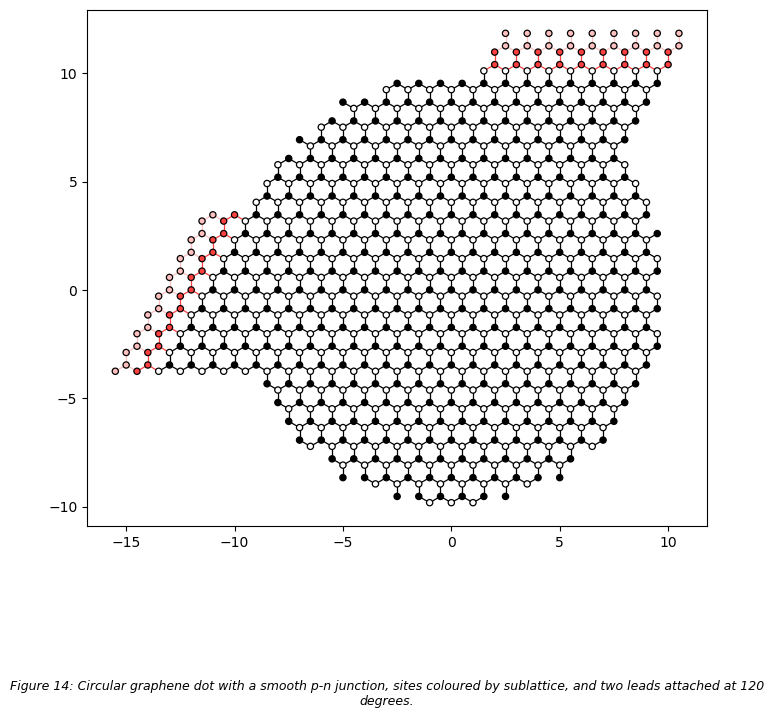

In [2]:
# --- Graphene quantum dot with a p-n junction and two leads ------------------
import kwant, numpy as np
from math import pi, sqrt, tanh
from matplotlib import pyplot

sin_30, cos_30 = 1/2, sqrt(3)/2

graphene = kwant.lattice.general([(1, 0), (sin_30, cos_30)],
                                 [(0, 0), (0, 1/sqrt(3))],
                                 norbs=1)
a_sub, b_sub = graphene.sublattices

r, w, pot = 10, 2.0, 0.1

def circle(pos):
    x, y = pos
    return x**2 + y**2 < r**2

def potential(site):
    x, y = site.pos
    d = y * cos_30 + x * sin_30
    return pot * tanh(d / w)          # smooth p-n junction across the dot

syst = kwant.Builder()
syst[graphene.shape(circle, (0, 0))] = potential

hoppings = (((0, 0), a_sub, b_sub),
            ((0, 1), a_sub, b_sub),
            ((-1, 1), a_sub, b_sub))
syst[[kwant.builder.HoppingKind(*h) for h in hoppings]] = -1

# two leads: one to the left, one to the top right
sym0 = kwant.TranslationalSymmetry(graphene.vec((-1, 0)))
def lead0_shape(pos):
    x, y = pos
    return -0.4 * r < y < 0.4 * r
lead0 = kwant.Builder(sym0)
lead0[graphene.shape(lead0_shape, (0, 0))] = -pot
lead0[[kwant.builder.HoppingKind(*h) for h in hoppings]] = -1

sym1 = kwant.TranslationalSymmetry(graphene.vec((0, 1)))
def lead1_shape(pos):
    v = pos[1] * sin_30 - pos[0] * cos_30
    return -0.4 * r < v < 0.4 * r
lead1 = kwant.Builder(sym1)
lead1[graphene.shape(lead1_shape, (0, 0))] = pot
lead1[[kwant.builder.HoppingKind(*h) for h in hoppings]] = -1

syst.attach_lead(lead0)
syst.attach_lead(lead1)

def family_colors(site):
    return 0 if site.family == a_sub else 1

kwant.plot(syst, site_color=family_colors, site_lw=0.1,
           colorbar=False, fig_size=(8, 8), show=False)
show_fig(r'Circular graphene dot with a smooth p-n junction, sites coloured by sublattice, and two leads attached at 120 degrees.')

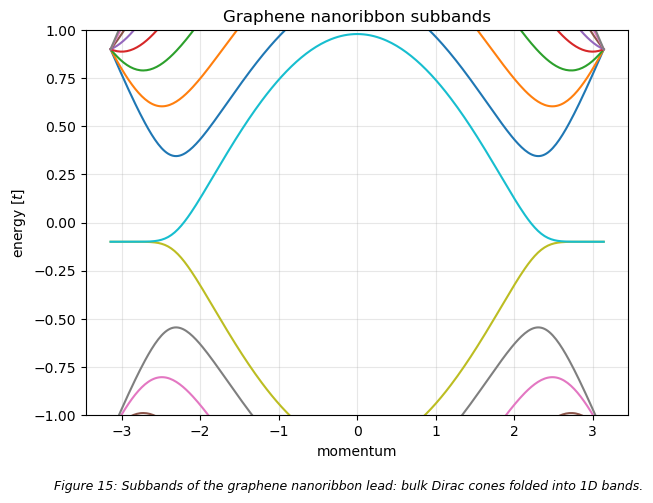

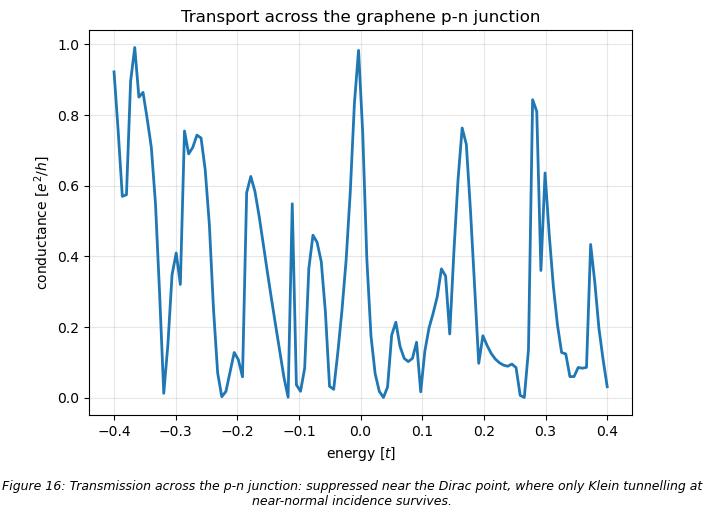

In [3]:
# --- Dirac cone in the lead band structure -----------------------------------
fgr = syst.finalized()

kwant.plotter.bands(fgr.leads[0], momenta=np.linspace(-pi, pi, 301), show=False)
pyplot.xlabel("momentum"); pyplot.ylabel("energy $[t]$")
pyplot.ylim(-1, 1); pyplot.title("Graphene nanoribbon subbands")
pyplot.grid(alpha=.3); show_fig(r'Subbands of the graphene nanoribbon lead: bulk Dirac cones folded into 1D bands.')

energies = np.linspace(-0.4, 0.4, 120)
G = [kwant.smatrix(fgr, e).transmission(0, 1) for e in energies]
pyplot.plot(energies, G, lw=2)
pyplot.xlabel("energy $[t]$"); pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("Transport across the graphene p-n junction")
pyplot.grid(alpha=.3); show_fig(r'Transmission across the p-n junction: suppressed near the Dirac point, where only Klein tunnelling at near-normal incidence survives.')

---
## 9. Superconductivity — BdG, Andreev reflection, and discrete symmetries

### The Bogoliubov–de Gennes construction

Superconductivity is not a single-particle problem, but mean-field BCS theory can be written
as one by **doubling the Hilbert space** into electron and hole components. In the
Nambu basis $\Psi = (\psi_\uparrow, \psi_\downarrow^\dagger)^T$,

$$H_{\text{BdG}} = \begin{pmatrix} H_0 - \mu & \Delta \\ \Delta^* & -(H_0 - \mu)^* \end{pmatrix}
= (H_0-\mu)\,\tau_z + \Delta\,\tau_x,$$

where $\tau_i$ are Pauli matrices **in electron–hole (Nambu) space**. So:

- `norbs=2` again — but now the two "orbitals" are electron and hole, not spin.
- On-site: $(4t - \mu)\tau_z + \Delta\tau_x$. Hopping: $-t\,\tau_z$ (holes hop with opposite sign).

The price of doubling is a **redundancy**: every eigenstate at $E$ has a partner at $-E$.
That is **particle–hole symmetry**, $\mathcal{P} H \mathcal{P}^{-1} = -H$ with
$\mathcal{P} = \tau_y \mathcal{K}$ in this basis. It is a *constraint*, not a symmetry that
labels states.

### Andreev reflection and the BTK conductance

At an N–S interface, an electron below the gap cannot enter the superconductor as a
quasiparticle. Instead it is retro-reflected as a **hole**, injecting a Cooper pair — this
is **Andreev reflection**. Because it converts an incoming electron into an outgoing hole,
it carries charge $2e$, and the conductance formula changes:

$$G = \frac{e^2}{h}\left(N - R_{ee} + R_{he}\right)$$

with $N$ the number of modes, $R_{ee}$ normal reflection and $R_{he}$ Andreev reflection.
For a **transparent** interface, $R_{he} \to N$ and $R_{ee}\to 0$ below the gap, so
$G \to 2Ne^2/h$ — **doubled** conductance. For a **tunnel barrier**, Andreev reflection is
suppressed as the square of the transparency, so $G \to 0$ below the gap and the curve maps
out the density of states. This crossover is the Blonder–Tinkham–Klapwijk result.

### Telling Kwant about the structure

```python
lead = kwant.Builder(sym, conservation_law=-tau_z, particle_hole=tau_y)
```

- `conservation_law=-tau_z` — electron and hole blocks do not mix *in the normal lead*
  (where $\Delta=0$). Kwant then **labels modes by block**, so you can ask for
  `transmission((0, 1), (0, 0))`: "from lead 0 block 0 to lead 0 block 1", i.e. exactly
  $R_{he}$. Blocks are ordered by ascending eigenvalue of the conservation law, so with
  `-tau_z` block 0 = electrons, block 1 = holes.
- `particle_hole=tau_y` — declares the antiunitary PHS, which lets Kwant relate scattering
  states at $\pm E$ and check consistency.

> Only impose `conservation_law` where it actually holds. In the superconducting lead
> $\Delta \ne 0$ mixes the blocks, so it must not be declared there.

*Further reading:* the barrier-strength crossover computed below is the
classic result of Blonder, Tinkham & Klapwijk, PRB **25**, 4515 (1982); the
scattering (Bogoliubov-de Gennes) formulation of superconducting transport is
reviewed in C. W. J. Beenakker, RMP **69**, 731 (1997), and pedagogically in
Nazarov & Blanter, *Quantum Transport* (Cambridge, 2009).


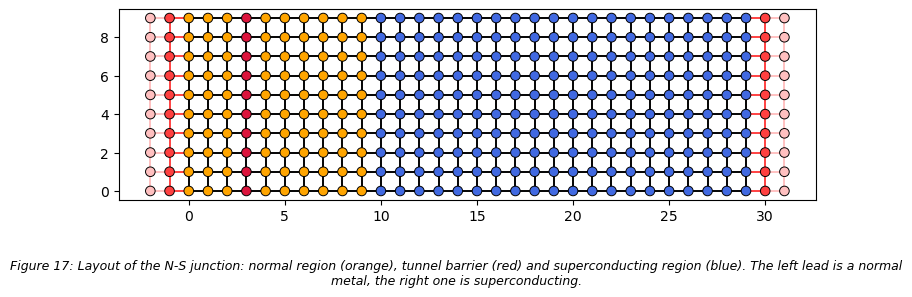

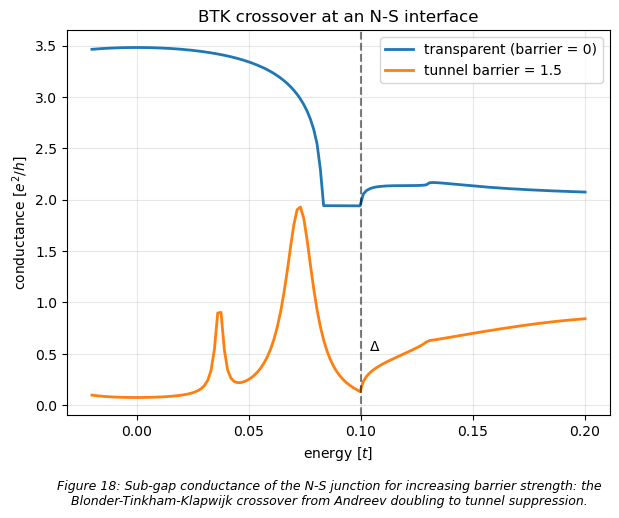

In [4]:
# --- N-S junction: Andreev reflection and the BTK crossover ------------------
import kwant, numpy as np, tinyarray
from matplotlib import pyplot

tau_x = tinyarray.array([[0, 1], [1, 0]])
tau_y = tinyarray.array([[0, -1j], [1j, 0]])
tau_z = tinyarray.array([[1, 0], [0, -1]])

a, t, W, L = 1, 1.0, 10, 30
mu, Delta, Deltapos = 0.4, 0.1, 10
lat = kwant.lattice.square(a, norbs=2)      # 2 orbitals = electron, hole

def make_ns(barrier=1.5, barrierpos=(3, 4)):
    syst = kwant.Builder()

    # normal part
    syst[(lat(x, y) for x in range(Deltapos) for y in range(W))] = \
        (4 * t - mu) * tau_z
    # superconducting part: pairing enters as an on-site tau_x term
    syst[(lat(x, y) for x in range(Deltapos, L) for y in range(W))] = \
        (4 * t - mu) * tau_z + Delta * tau_x
    # tunnel barrier controls the interface transparency
    syst[(lat(x, y) for x in range(*barrierpos) for y in range(W))] = \
        (4 * t + barrier - mu) * tau_z

    syst[lat.neighbors()] = -t * tau_z

    # left lead: NORMAL -> electrons and holes decouple, so declare it
    lead0 = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)),
                          conservation_law=-tau_z, particle_hole=tau_y)
    lead0[(lat(0, j) for j in range(W))] = (4 * t - mu) * tau_z
    lead0[lat.neighbors()] = -t * tau_z

    # right lead: SUPERCONDUCTING -> no conservation law here
    lead1 = kwant.Builder(kwant.TranslationalSymmetry((a, 0)))
    lead1[(lat(0, j) for j in range(W))] = (4 * t - mu) * tau_z + Delta * tau_x
    lead1[lat.neighbors()] = -t * tau_z

    syst.attach_lead(lead0)
    syst.attach_lead(lead1)
    return syst.finalized()

fns_plot = make_ns()
def ns_region_color(i):
    # NB: for a *finalized* system the callable receives the site index
    x = fns_plot.sites[i].pos[0]
    if 3 <= x < 4:
        return 'crimson'                    # tunnel barrier
    return 'orange' if x < Deltapos else 'royalblue'

kwant.plot(fns_plot, site_color=ns_region_color, site_lw=0.05,
           colorbar=False, fig_size=(9, 3), show=False)
show_fig(r'Layout of the N-S junction: normal region (orange), tunnel barrier (red) and superconducting region (blue). The left lead is a normal metal, the right one is superconducting.')

def andreev_conductance(fsyst, energies):
    G = []
    for e in energies:
        s = kwant.smatrix(fsyst, e)
        N    = s.submatrix((0, 0), (0, 0)).shape[0]   # number of electron modes
        R_ee = s.transmission((0, 0), (0, 0))         # normal reflection
        R_he = s.transmission((0, 1), (0, 0))         # ANDREEV reflection
        G.append(N - R_ee + R_he)
    return np.array(G)

energies = np.linspace(-0.02, 0.2, 150)

pyplot.figure()
for barrier, label in [(0.0, "transparent (barrier = 0)"),
                       (1.5, "tunnel barrier = 1.5")]:
    fsyst_ns = make_ns(barrier=barrier)
    pyplot.plot(energies, andreev_conductance(fsyst_ns, energies),
                lw=2, label=label)

pyplot.axvline(Delta, ls='--', c='k', alpha=.5)
pyplot.text(Delta, 0.5, r"  $\Delta$", va='bottom')
pyplot.xlabel("energy $[t]$"); pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("BTK crossover at an N-S interface")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Sub-gap conductance of the N-S junction for increasing barrier strength: the Blonder-Tinkham-Klapwijk crossover from Andreev doubling to tunnel suppression.')

In [5]:
# --- Verifying particle-hole symmetry of the scattering matrix ---------------
fsyst_ns = make_ns(barrier=0.0)

s = kwant.smatrix(fsyst_ns, energy=0)
s_ee = s.submatrix((0, 0), (0, 0))     # electron -> electron
s_hh = s.submatrix((0, 1), (0, 1))     # hole -> hole

print("s_ee =\n", np.round(s_ee, 4))
print("\ns_hh =\n", np.round(s_hh, 4))
print("\nPHS at E=0 requires  s_ee = conj(s_hh):")
print("max deviation = %.2e" % np.max(np.abs(s_ee - s_hh.conj())))

s_ee =
 [[-0.1639+0.0281j -0.    -0.j    ]
 [ 0.    -0.j     -0.4545-0.1581j]]

s_hh =
 [[-0.4545+0.1581j  0.    -0.j    ]
 [ 0.    -0.j     -0.1639-0.0281j]]

PHS at E=0 requires  s_ee = conj(s_hh):
max deviation = 3.45e-01
